In [1]:
import pandas as pd
import numpy as np
import os

os.chdir(r"data_acquisition")
os.getcwd()

brfss1 = pd.read_parquet("BRFSS_2024_1.parquet.gzip")
brfss2 =  pd.read_parquet("BRFSS_2024_2.parquet.gzip")

In [2]:
# Merging the two sets
brfss = pd.concat([brfss1, brfss2], axis = 0)
brfss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Columns: 301 entries, _STATE to _AIDTST4
dtypes: float64(296), object(5)
memory usage: 1.0+ GB


In [3]:
# Selecting Relevant Variables

cols = ["_AGE_G", "SEXVAR","_BMI5","_RFBMI5","HTM4", "_TOTINDA","WTKG3", "_RFSMOK3",
        "_RFDRHV9","_EDUCAG" , "_INCOMG1","DIABETE4", "ASTHNOW", "CHCKDNY2", "_DRDXAR2"]

brfss = brfss[cols]
brfss.head()

,_AGE_G,SEXVAR,_BMI5,_RFBMI5,HTM4,_TOTINDA,WTKG3,_RFSMOK3,_RFDRHV9,_EDUCAG,_INCOMG1,DIABETE4,ASTHNOW,CHCKDNY2,_DRDXAR2
0,6.0,2.0,2249.0,1.0,163.0,1.0,5942.0,1.0,1.0,2.0,9.0,3.0,NaN,2.0,1.0
1,6.0,1.0,2583.0,2.0,178.0,1.0,8165.0,1.0,1.0,4.0,7.0,3.0,NaN,2.0,1.0
2,5.0,1.0,2253.0,1.0,198.0,1.0,8845.0,2.0,1.0,3.0,9.0,3.0,NaN,2.0,1.0
3,6.0,1.0,2509.0,2.0,173.0,1.0,7484.0,1.0,1.0,4.0,4.0,3.0,NaN,2.0,1.0
4,4.0,1.0,1977.0,1.0,173.0,2.0,5897.0,1.0,1.0,3.0,2.0,3.0,NaN,2.0,2.0


In [4]:
# Renaming Variables

brfss = brfss.rename(columns={ "SEXVAR": "Sex",
                           "_BMI5": "BMI",
                           "_AGE_G": "Age_group",
                           "_RFBMI5": "Obese",
                           "HTM4": "Height_in_m",
                           "_TOTINDA": "Physical_Activity",
                           "WTKG3": "Weight_in_kg",
                           "_RFSMOK3": "Smoker",
                           "_RFDRHV9": "Heavy_Drinker",
                           "_EDUCAG": "Education_level",
                           "_INCOMG1": "Income_Cat",
                             "DIABETE4": "Diabetes",
                             "ASTHNOW": "Asthma",
                             "CHCKDNY2": "Kidney_Disease",
                             "_DRDXAR2": "Arthritis"
                         })
brfss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age_group          457670 non-null  float64
 1   Sex                457670 non-null  float64
 2   BMI                414633 non-null  float64
 3   Obese              457670 non-null  float64
 4   Height_in_m        433610 non-null  float64
 5   Physical_Activity  457670 non-null  float64
 6   Weight_in_kg       421278 non-null  float64
 7   Smoker             457670 non-null  float64
 8   Heavy_Drinker      457670 non-null  float64
 9   Education_level    457670 non-null  float64
 10  Income_Cat         457670 non-null  float64
 11  Diabetes           457666 non-null  float64
 12  Asthma             72037 non-null   float64
 13  Kidney_Disease     457664 non-null  float64
 14  Arthritis          455097 non-null  float64
dtypes: float64(15)
memory usage: 52.4 MB


# Recoding Variables from Numeric to Categorical Format

In [5]:

# Mapping Values In Categorical Variables ... Changing them From Numeric to Categories

# INCOME

# Converting  income var to integer
brfss["Income_Cat"] = brfss["Income_Cat"].astype("Int64")

# Ordered income categories
income_order = [
        "Less than $15,000",
        "$15,000 < $25,000",
        "$25,000 < $35,000",
        "$35,000 < $50,000",
        "$50,000 < $100,000",
        "$100,000 < $200,000",
        "$200,000 or more",
        "Missing/Don’t know",
]

# Replacing numeric codes with categories
brfss["Income_Cat"] = pd.Categorical(
    brfss["Income_Cat"].map({
        1: "Less than $15,000",
        2: "$15,000 < $25,000",
        3: "$25,000 < $35,000",
        4: "$35,000 < $50,000",
        5: "$50,000 < $100,000",
        6: "$100,000 < $200,000",
        7: "$200,000 or more",
        9: np.nan
    }),
    categories = income_order,
    ordered = True
)

# EDUCATION

# Converting  education variable to integer
brfss["Education_level"] = brfss["Education_level"].astype("Int64")

# Ordered education categories
education_order = [
    "Did not graduate High School",
    "Graduated High School",
    "Attended College or Technical School",
    "Graduated from College or Technical School",
    "Don’t know/Not sure/Missing"
]

# Replace numeric codes with categories and create an ordered categorical
brfss["Education_level"] = pd.Categorical(
    brfss["Education_level"].map({
        1: "Did not graduate High School",
        2: "Graduated High School",
        3: "Attended College or Technical School",
        4: "Graduated from College or Technical School",
        9: np.nan
    }),
    categories=education_order,
    ordered=True
)

# ALCOHOL

# Converting the column to integer
brfss["Heavy_Drinker"] = brfss["Heavy_Drinker"].astype("Int64")

# Map numeric codes
brfss["Heavy_Drinker"] = pd.Categorical(
    brfss["Heavy_Drinker"].map({
        1: "No",
        2: "Yes",
        9: np.nan
    })
)

# SMOKING

# Converting  column to integer
brfss["Smoker"] = brfss["Smoker"].astype("Int64")

# Map numeric codes to categor
brfss["Smoker"] = pd.Categorical(
    brfss["Smoker"].map({
        1: "No",
        2: "Yes",
        9: np.nan
    })
)

# OBESE

# Converting column to integer
brfss["Obese"] = brfss["Obese"].astype("Int64")

# Mapping numeric codes to categories
brfss["Obese"] = brfss["Obese"].map({
    1: "No",
    2: "Yes",
    9: np.nan
})

# SEX

# Converting to integer
brfss["Sex"] = brfss["Sex"].astype("Int64")

# Mapping numeric codes to categories
brfss["Sex"] = brfss["Sex"].map({
    1: "Male",
    2: "Female"
})

# AGE GROUP

# Converting column to integer
brfss["Age_group"] = brfss["Age_group"].astype("Int64")

# Defining the ordered categories
age_order = [
    "Age 18 to 24",
    "Age 25 to 34",
    "Age 35 to 44",
    "Age 45 to 54",
    "Age 55 to 64",
    "Age 65 or older"
]

# Map numeric codes to categories
brfss["Age_group"] = pd.Categorical(
    brfss["Age_group"].map({
        1: "Age 18 to 24",
        2: "Age 25 to 34",
        3: "Age 35 to 44",
        4: "Age 45 to 54",
        5: "Age 55 to 64",
        6: "Age 65 or older"
    }),
    categories=age_order,
    ordered=True
)

# PHYSICAL ACTIVITY

# Converting column to integer
brfss["Physical_Activity"] = brfss["Physical_Activity"].astype("Int64")

brfss["Physical_Activity"] = pd.Categorical(
    brfss["Physical_Activity"].map({
        1: "Had physical activity or exercise",
        2: "No physical activity or exercise in last 30 days",
        9: np.nan
    })
)

# ASTHMA

brfss["Asthma"] = pd.Categorical(
    brfss["Asthma"].map({
        1: "Yes",
        2: "No",
        7: np.nan,
        9: np.nan
    })
)

# DIABETES

brfss["Diabetes"] = pd.Categorical(
    brfss["Diabetes"].map({
        1: "Yes",
        2: "No",
        3: "No",
        4: "No",
        7: np.nan,
        9: np.nan
    })
)

# KIDNEY DISEASE

brfss["Kidney_Disease"] = pd.Categorical(
    brfss["Kidney_Disease"].map({
        1: "Yes",
        2: "No",
        7: np.nan,
        9: np.nan
    })
)

# ARTHRITIS

brfss["Arthritis"] = pd.Categorical(
    brfss["Arthritis"].map({
        1: "Yes",
        2: "No"
    })
)



# Summary statistics

In [6]:
# Age Group distribution

brfss['Age_group'].value_counts()

Age_group
Age 65 or older    172826
Age 55 to 64        80280
Age 45 to 54        64458
Age 35 to 44        60418
Age 25 to 34        49994
Age 18 to 24        29694
Name: count, dtype: int64

In [7]:
# Education Level distribution

brfss['Education_level'].value_counts()

Education_level
Graduated from College or Technical School    191549
Attended College or Technical School          120732
Graduated High School                         115877
Did not graduate High School                   27149
Don’t know/Not sure/Missing                        0
Name: count, dtype: int64

In [8]:
# Income distribution

brfss['Income_Cat'].value_counts()

Income_Cat
$50,000 < $100,000     112409
$100,000 < $200,000     82453
$35,000 < $50,000       49686
$25,000 < $35,000       41702
$15,000 < $25,000       33503
$200,000 or more        29694
Less than $15,000       20800
Missing/Don’t know          0
Name: count, dtype: int64

In [9]:
# Physical Activities  distribution

brfss['Physical_Activity'].value_counts()

Physical_Activity
Had physical activity or exercise                   350061
No physical activity or exercise in last 30 days    106294
Name: count, dtype: int64

In [10]:
brfss.describe(include = "category")

,Age_group,Physical_Activity,Smoker,Heavy_Drinker,Education_level,Income_Cat,Diabetes,Asthma,Kidney_Disease,Arthritis
count,457670,456355,425648,410972,455307,370247,456636,69961,455691,455097
unique,6,2,2,2,4,7,2,2,2,2
top,Age 65 or older,Had physical activity or exercise,No,No,Graduated from College or Technical School,"$50,000 < $100,000",No,Yes,No,No
freq,172826,350061,378554,386812,191549,112409,390827,49694,431939,296778


# Correlation (Heatmap) for numeric variables

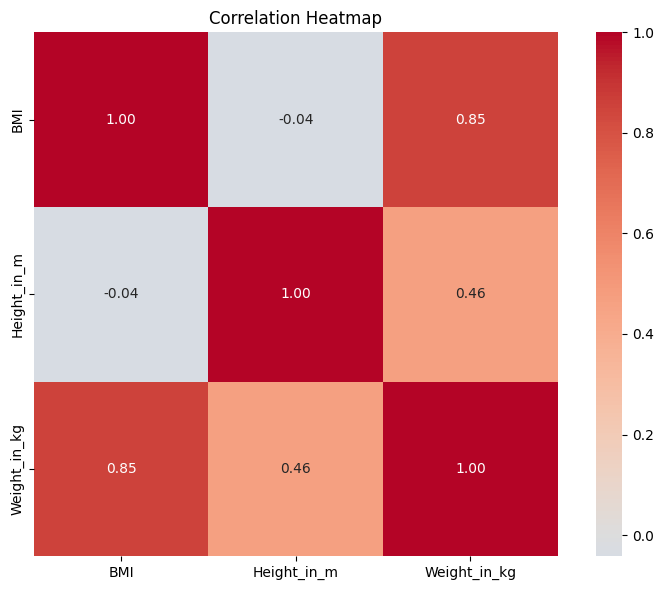

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

num_vars = brfss[['BMI', 'Height_in_m', 'Weight_in_kg']]

cor_matrix = num_vars.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Findings and Conclusion

The correlation analysis revealed a strong positive correlation between BMI and Weight (r = 0.85), indicating the presence of multicollinearity. Since BMI is mathematically derived from both height and weight, retaining all three variables simultaneously would introduce redundant information that could distort model estimates and inflate standard errors. Therefore, Height and Weight were excluded from the model, retaining only BMI as the anthropometric predictor, as it provides a clinically meaningful and non-redundant summary of both measures

In [6]:
# Dropping Leakage Vars

leakage_cols = ["Height_in_m", "Weight_in_kg", "Obese"]
brfss = brfss.drop(columns= leakage_cols)
brfss.head()

,Age_group,Sex,BMI,Physical_Activity,Smoker,Heavy_Drinker,Education_level,Income_Cat,Diabetes,Asthma,Kidney_Disease,Arthritis
0,Age 65 or older,Female,2249.0,Had physical activity or exercise,No,No,Graduated High School,NaN,No,NaN,No,Yes
1,Age 65 or older,Male,2583.0,Had physical activity or exercise,No,No,Graduated from College or Technical School,"$200,000 or more",No,NaN,No,Yes
2,Age 55 to 64,Male,2253.0,Had physical activity or exercise,Yes,No,Attended College or Technical School,NaN,No,NaN,No,Yes
3,Age 65 or older,Male,2509.0,Had physical activity or exercise,No,No,Graduated from College or Technical School,"$35,000 < $50,000",No,NaN,No,Yes
4,Age 45 to 54,Male,1977.0,No physical activity or exercise in last 30 days,No,No,Attended College or Technical School,"$15,000 < $25,000",No,NaN,No,No


# Data Preprocessing and Feature Engineering

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Ordinal Columns
ordinal_cols = ["Age_group", "Education_level", "Income_Cat"]

# Binary Columns
binary_cols = ["Sex", "Smoker", "Heavy_Drinker", "Physical_Activity",
               "Asthma", "Kidney_Disease", "Arthritis"]

# Numeric Columns
numeric_cols = ["BMI"]

# Clean and align X and y FIRST before anything else
X = brfss[ordinal_cols + binary_cols + numeric_cols]
y = brfss['Diabetes']

mask = y.notna()
X = X[mask]
y = y[mask]

# Encode y
le = LabelEncoder()
y = le.fit_transform(y)

# Ordinal
ordinal_orders = [
    ["Age 18 to 24", "Age 25 to 34", "Age 35 to 44",
     "Age 45 to 54", "Age 55 to 64", "Age 65 or older"],
    ["Did not graduate High School", "Graduated High School",
     "Attended College or Technical School",
     "Graduated from College or Technical School",
     "Don't know/Not sure/Missing"],
    ["Less than $15,000", "$15,000 < $25,000", "$25,000 < $35,000",
     "$35,000 < $50,000", "$50,000 < $100,000",
     "$100,000 < $200,000", "$200,000 or more", "Missing/Don't know"],
]

ordinal_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(
        categories=ordinal_orders,
        handle_unknown="use_encoded_value",
        unknown_value=np.nan
    )),
])

# Binary

binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Numeric

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', ordinal_pipeline, ordinal_cols),
        ('binary',  binary_pipeline,  binary_cols),
        ('numeric', numeric_pipeline, numeric_cols),
    ], remainder='drop'
)


# Data split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Fit preprocessor on train only, transform both
X_train_processed = preprocessor.fit_transform(X_train)   # learns encoding from train only
X_test_processed  = preprocessor.transform(X_test)        # applies same encoding to test

# Applying SMOTE on training data only AFTER preprocessing
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

smote = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

# Summary check
print("X_train shape (resampled):", X_train_resampled.shape)
print("X_test shape             :", X_test_processed.shape)
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

X_train shape (resampled): (576536, 11)
X_test shape             : (91328, 11)

Class distribution after SMOTE:
0    288268
1    288268
Name: count, dtype: int64


# Modelling

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score,f1_score
import pandas as pd

def run_classifier(classifier, X_train, y_train, X_test, y_test):
    """
    Parameters
    ----------
    classifier : any sklearn-compatible classifier
    X_train    : preprocessed + SMOTE resampled training features
    y_train    : resampled training labels
    X_test     : preprocessed test features (no SMOTE)
    y_test     : original test labels
    """

    # 5-fold CV on resampled training data
    cv_scores = cross_val_score(
        classifier, X_train, y_train,
        scoring='f1_macro',
        cv=5,
        n_jobs=-1
    )

    print(f"\n{classifier.__class__.__name__}")
    print(f"CV F1 scores : {cv_scores.round(4)}")
    print(f"  Macro  F1  : {macro_f1:.4f} ")
    print(f"Mean F1      : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    # Fit and evaluate
    classifier.fit(X_train, y_train)
    y_proba = classifier.predict_proba(X_test)[:, 1]
    y_pred  = classifier.predict(X_test)

    print(f"\n{classification_report(y_test, y_pred, target_names=['No', 'Yes'])}")
    print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR-AUC  : {average_precision_score(y_test, y_proba):.4f}")
    macro_f1  = f1_score(y_test, y_pred, average='macro')


    # Feature importance (if supported)
    if hasattr(classifier, 'feature_importances_'):
        fi = pd.DataFrame({
            'Feature':    ordinal_cols + binary_cols + numeric_cols,
            'Importance': classifier.feature_importances_
        }).sort_values('Importance', ascending=False)
        print(f"\n{fi.to_string(index=False)}")

    return cv_scores, classifier

# Random Forest

In [9]:
# Random Forest
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
cv_scores, rf_model = run_classifier(rf, X_train_resampled, y_train_resampled, X_test_processed, y_test)


UnboundLocalError: cannot access local variable 'y_pred' where it is not associated with a value

# XGBoost

In [18]:
# XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight= 0.5, n_estimators=300, learning_rate=0.05, random_state=42)
cv_scores, xgb_model = run_classifier(xgb, X_train_resampled, y_train_resampled, X_test_processed, y_test)


UnboundLocalError: cannot access local variable 'y_pred' where it is not associated with a value

In [42]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter distribution for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(100, 500), # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.3), # Step size shrinkage
    'max_depth': randint(3, 10), # Maximum depth of a tree
    'subsample': uniform(0.6, 0.4), # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree
    'gamma': uniform(0, 0.5), # Minimum loss reduction required to make a further partition
    'lambda': uniform(1, 2), # L2 regularization term on weights (xgb's lambda)
    'alpha': uniform(0, 0.5) # L1 regularization term on weights (xgb's alpha)
}

# Initialize XGBoost Classifier
# Using scale_pos_weight for handling imbalanced classes, as done in the previous XGBoost cell
# For Random Search CV, it's often better to let the CV search for optimal 'scale_pos_weight' if it's a parameter,
# or keep it constant if the imbalance ratio is fixed.
xgb_base = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, n_jobs=-1)

# Setup RandomizedSearchCV
# n_iter determines the number of parameter settings that are sampled.
# cv is the number of folds for cross-validation.
# scoring='f1_macro' to align with the previous evaluations.
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting Randomized Search CV for XGBoost...")

# Fitting RandomizedSearchCV on the resampled training data
random_search.fit(X_train_resampled, y_train_resampled)

# Get the best estimator
best_xgb_model = random_search.best_estimator_

print(f"\nBest parameters found: {random_search.best_params_}")
print(f"Best cross-validation f1_macro score: {random_search.best_score_:.4f}")

# Evaluate the best model using the run_classifier function
print("\nEvaluating the best XGBoost model found by Randomized Search CV:")
cv_scores_tuned, xgb_tuned_model = run_classifier(
    best_xgb_model,
    X_train_resampled,
    y_train_resampled,
    X_test_processed,
    y_test
)

Starting Randomized Search CV for XGBoost...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Randomized Search CV completed.

Best parameters found: {'alpha': np.float64(0.27461333235306024), 'colsample_bytree': np.float64(0.8858383690800249), 'gamma': np.float64(0.33009868835886563), 'lambda': np.float64(1.5598677938918857), 'learning_rate': np.float64(0.29645958419895824), 'max_depth': 9, 'n_estimators': 291, 'subsample': np.float64(0.8217416210045603)}
Best cross-validation f1_macro score: 0.7747

Evaluating the best XGBoost model found by Randomized Search CV:

XGBClassifier
CV F1 scores : [0.7289 0.7858 0.7907 0.7873 0.7859]
Mean F1      : 0.7757 (+/- 0.0235)

              precision    recall  f1-score   support

          No       0.86      0.67      0.75     78231
         Yes       0.14      0.33      0.20     13097

    accuracy                           0.62     91328
   macro avg       0.50      0.50      0.48     91328
weighted avg       0.75      0.62      0